In [1]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 3050 Laptop GPU


In [2]:
from pathlib import Path
import sys

current = Path.cwd().resolve()

for parent in [current] + list(current.parents):
    if (parent / "src").exists():
        PROJECT_ROOT = parent
        SRC_PATH = parent / "src"
        break
else:
    raise FileNotFoundError("Cannot find project root with src folder.")


for path in [PROJECT_ROOT, SRC_PATH]:
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

print("Project root:", PROJECT_ROOT)
print("Src path:", SRC_PATH)

import config
import transforms

print("config imported from:", config.__file__)
print("transforms imported from:", transforms.__file__)




Project root: C:\Users\Lv043\OneDrive\Desktop\760proj\760-Group1
Src path: C:\Users\Lv043\OneDrive\Desktop\760proj\760-Group1\src
config imported from: C:\Users\Lv043\OneDrive\Desktop\760proj\760-Group1\src\config.py
transforms imported from: C:\Users\Lv043\OneDrive\Desktop\760proj\760-Group1\src\transforms.py


In [3]:
import time
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from src.config import (
    DEVICE,
    NUM_EPOCHS,
    RANDOM_SEED,
    MODEL_DIR,
    RESULT_DIR,
    FIGURE_DIR,
    CLASS_NAMES,
)

from src.dataset import get_dataloaders
from src.metrics import calculate_classification_metrics
from src.transfer_models_DenseNet.densenet121_model import get_densenet121

MODEL_NAME = "densenet121"
LEARNING_RATE = 0.0001
PATIENCE = 5

print("Device from config:", DEVICE)
print("Number of epochs:", NUM_EPOCHS)
print("Classes:", CLASS_NAMES)




Device from config: cuda
Number of epochs: 20
Classes: ['Normal', 'Doubtful', 'Mild', 'Moderate', 'Severe']


In [4]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(RANDOM_SEED)

MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device(DEVICE)

print("Using device:", device)




Using device: cuda


In [5]:
train_loader, val_loader, test_loader = get_dataloaders()

print("DataLoader info:")
print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")




DataLoader info:
Train batches: 64
Validation batches: 10
Test batches: 19


rennet model

In [6]:
train_loader, val_loader, test_loader = get_dataloaders()

print("DataLoader info:")
print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")




DataLoader info:
Train batches: 64
Validation batches: 10
Test batches: 19


improve densenet + ordinal aware loss v2

In [7]:
# Improved DenseNet121 v2 + Ordinal-aware Loss

from torchvision import models
import torch.nn.functional as F

MODEL_VERSION = "improved_densenet121_ordinal_v2"

NUM_CLASSES = len(CLASS_NAMES)

# Hyperparameters
ORDINAL_ALPHA = 0.3
DROPOUT = 0.2
HIDDEN_FEATURES = 512

LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
PATIENCE = 5

MAX_EPOCHS = 20


def get_densenet121_improved_v2(
    num_classes=5,
    pretrained=True,
    dropout=0.2,
    hidden_features=512,
    fine_tune_last_block=True
):
    """
    Improved DenseNet121 v2:
    - DenseNet121 pretrained backbone
    - Dropout-based classifier head
    - Fine-tune classifier + denseblock4 + norm5
    """

    try:
        from torchvision.models import DenseNet121_Weights
        weights = DenseNet121_Weights.DEFAULT if pretrained else None
        model = models.densenet121(weights=weights)
    except Exception:
        model = models.densenet121(pretrained=pretrained)

    # Freeze all parameters first
    for param in model.parameters():
        param.requires_grad = False

    # Replace classifier head
    in_features = model.classifier.in_features

    model.classifier = nn.Sequential(
        nn.Dropout(dropout),
        nn.Linear(in_features, hidden_features),
        nn.ReLU(),
        nn.Dropout(dropout),
        nn.Linear(hidden_features, num_classes)
    )

    # Train classifier head
    for param in model.classifier.parameters():
        param.requires_grad = True

    # Fine-tune last DenseNet block
    if fine_tune_last_block:
        for param in model.features.denseblock4.parameters():
            param.requires_grad = True

        for param in model.features.norm5.parameters():
            param.requires_grad = True

    return model


class OrdinalAwareLoss(nn.Module):
    """
    Ordinal-aware loss for KL grade classification.

    Loss = CrossEntropyLoss + alpha * ordinal distance penalty
    """

    def __init__(self, num_classes=5, alpha=0.3):
        super().__init__()
        self.num_classes = num_classes
        self.alpha = alpha

    def forward(self, logits, targets):
        # Standard CrossEntropyLoss
        ce_loss = F.cross_entropy(
            logits,
            targets,
            reduction="none"
        )

        # Convert logits to probabilities
        probs = F.softmax(logits, dim=1)

        # Class indices: [0, 1, 2, 3, 4]
        class_indices = torch.arange(
            self.num_classes,
            device=logits.device,
            dtype=torch.float32
        )

        # Expected predicted KL grade
        expected_grade = torch.sum(probs * class_indices, dim=1)

        # Ordinal distance penalty
        ordinal_penalty = torch.abs(expected_grade - targets.float())

        # Final loss
        loss = ce_loss + self.alpha * ordinal_penalty

        return loss.mean()


def count_trainable_parameters(model):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return trainable_params, total_params


# Build model
model = get_densenet121_improved_v2(
    num_classes=NUM_CLASSES,
    pretrained=True,
    dropout=DROPOUT,
    hidden_features=HIDDEN_FEATURES,
    fine_tune_last_block=True
).to(device)

# Loss
criterion = OrdinalAwareLoss(
    num_classes=NUM_CLASSES,
    alpha=ORDINAL_ALPHA
).to(device)

# Optimizer
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

# Scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

trainable_params, total_params = count_trainable_parameters(model)

print("=" * 60)
print("Improved DenseNet121 v2 + Ordinal-aware Loss")
print("=" * 60)
print(f"Model version: {MODEL_VERSION}")
print(f"Trainable parameters: {trainable_params:,} / {total_params:,}")
print(f"Ordinal alpha: {ORDINAL_ALPHA}")
print(f"Dropout: {DROPOUT}")
print(f"Hidden features: {HIDDEN_FEATURES}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Weight decay: {WEIGHT_DECAY}")
print(f"Max epochs: {MAX_EPOCHS}")
print(f"Patience: {PATIENCE}")




Improved DenseNet121 v2 + Ordinal-aware Loss
Model version: improved_densenet121_ordinal_v2
Trainable parameters: 2,687,493 / 7,481,221
Ordinal alpha: 0.3
Dropout: 0.2
Hidden features: 512
Learning rate: 0.0001
Weight decay: 0.0001
Max epochs: 20
Patience: 5


In [8]:
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, dim=1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc


def evaluate_one_epoch(model, data_loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, dim=1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc




remove stage change to normal

In [9]:
# Train Improved DenseNet121 v2

best_val_loss = float("inf")
best_val_acc = 0.0
epochs_without_improvement = 0

best_model_path = MODEL_DIR / f"{MODEL_VERSION}_best.pth"
history_path = RESULT_DIR / f"{MODEL_VERSION}_training_history.csv"

history = {
    "epoch": [],
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "learning_rate": [],
}

start_time = time.time()

print("=" * 60)
print("Training Improved DenseNet121 v2 + Ordinal-aware Loss")
print("=" * 60)
print(f"Device: {device}")
print(f"Epochs: {MAX_EPOCHS}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Ordinal alpha: {ORDINAL_ALPHA}")
print(f"Dropout: {DROPOUT}")

for epoch in range(1, MAX_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(
        model=model,
        train_loader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device
    )

    val_loss, val_acc = evaluate_one_epoch(
        model=model,
        data_loader=val_loader,
        criterion=criterion,
        device=device
    )

    current_lr = optimizer.param_groups[0]["lr"]

    history["epoch"].append(epoch)
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["learning_rate"].append(current_lr)

    print(
        f"Epoch [{epoch}/{MAX_EPOCHS}] "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"LR: {current_lr:.8f}"
    )

    # Save best model based on validation loss
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_val_acc = val_acc
        epochs_without_improvement = 0

        torch.save(model.state_dict(), best_model_path)
        print(f"Best model saved: {best_model_path}")
    else:
        epochs_without_improvement += 1
        print(f"No improvement: {epochs_without_improvement}/{PATIENCE}")

    # Step scheduler after validation
    scheduler.step(val_loss)

    # Early stopping
    if epochs_without_improvement >= PATIENCE:
        print("Early stopping triggered.")
        break

end_time = time.time()
training_time = end_time - start_time

history_df = pd.DataFrame(history)
history_df.to_csv(history_path, index=False)

print("\n" + "=" * 60)
print("Training finished")
print("=" * 60)
print(f"Best validation loss: {best_val_loss:.4f}")
print(f"Best validation accuracy: {best_val_acc:.4f}")
print(f"Epochs trained: {len(history['epoch'])}")
print(f"Training time: {training_time:.2f} seconds")
print(f"History saved to: {history_path}")
print(f"Best model saved to: {best_model_path}")




Training Improved DenseNet121 v2 + Ordinal-aware Loss
Device: cuda
Epochs: 20
Learning rate: 0.0001
Ordinal alpha: 0.3
Dropout: 0.2
Epoch [1/20] Train Loss: 1.7287 | Train Acc: 0.3877 | Val Loss: 1.4229 | Val Acc: 0.5137 | LR: 0.00010000
Best model saved: C:\Users\Lv043\OneDrive\Desktop\760proj\760-Group1\outputs\models\improved_densenet121_ordinal_v2_best.pth
Epoch [2/20] Train Loss: 1.3061 | Train Acc: 0.5693 | Val Loss: 1.0682 | Val Acc: 0.6986 | LR: 0.00010000
Best model saved: C:\Users\Lv043\OneDrive\Desktop\760proj\760-Group1\outputs\models\improved_densenet121_ordinal_v2_best.pth
Epoch [3/20] Train Loss: 1.0272 | Train Acc: 0.6738 | Val Loss: 0.9467 | Val Acc: 0.6986 | LR: 0.00010000
Best model saved: C:\Users\Lv043\OneDrive\Desktop\760proj\760-Group1\outputs\models\improved_densenet121_ordinal_v2_best.pth
Epoch [4/20] Train Loss: 0.8874 | Train Acc: 0.7188 | Val Loss: 0.8784 | Val Acc: 0.7329 | LR: 0.00010000
Best model saved: C:\Users\Lv043\OneDrive\Desktop\760proj\760-Group1\

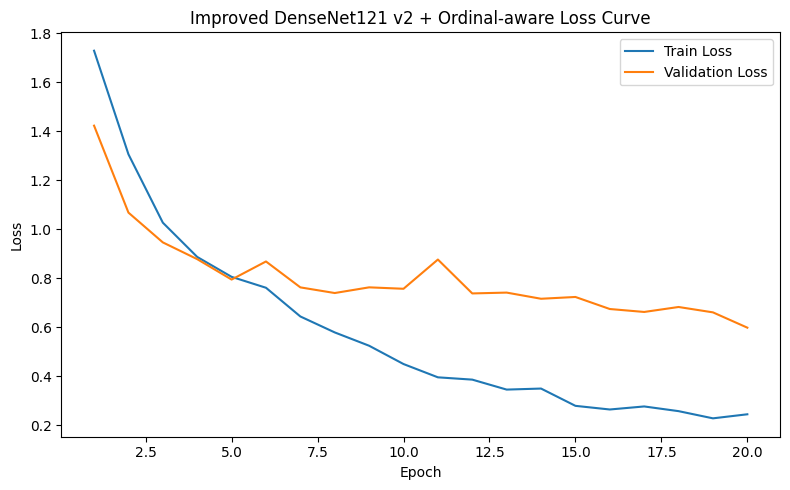

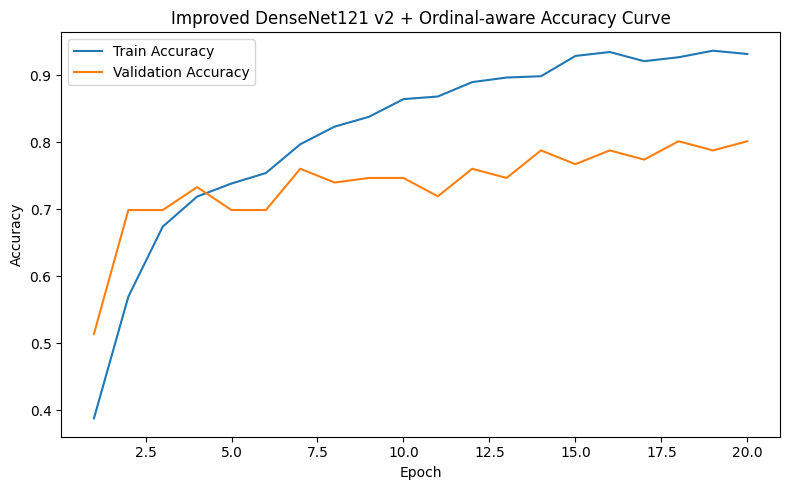

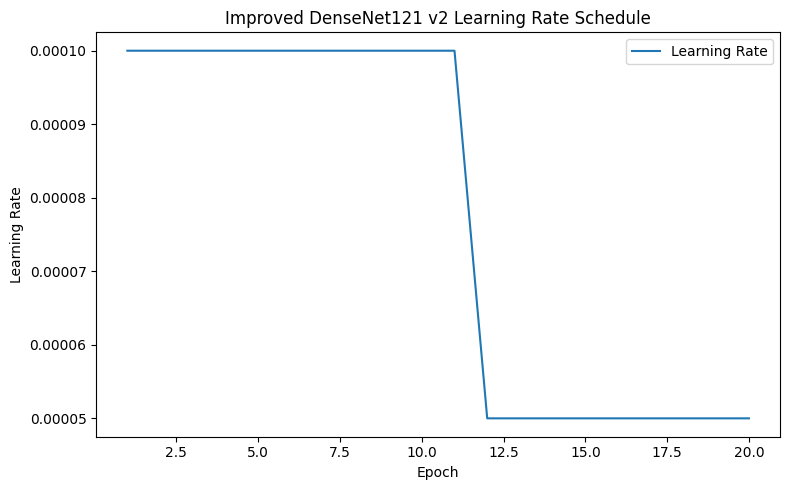

In [10]:
epochs = history["epoch"]

plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Improved DenseNet121 v2 + Ordinal-aware Loss Curve")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_acc"], label="Train Accuracy")
plt.plot(epochs, history["val_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Improved DenseNet121 v2 + Ordinal-aware Accuracy Curve")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs, history["learning_rate"], label="Learning Rate")
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("Improved DenseNet121 v2 Learning Rate Schedule")
plt.legend()
plt.tight_layout()
plt.show()




Evaluating Improved DenseNet121 v2 + Ordinal-aware Loss on Test Set


C:\Users\Lv043\AppData\Local\Temp\ipykernel_38068\1041871840.py:44: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  test_model.load_state_dict(torch.load(model_path, map_locat


Overall Test Metrics:
accuracy: 0.7687
macro_f1: 0.7455
weighted_f1: 0.7662
mae: 0.3333
qwk: 0.8354
total_errors: 68
adjacent_errors: 48
distant_errors: 20
adjacent_error_rate_among_errors: 0.7059
distant_error_rate_among_errors: 0.2941

Per-Class Metrics:


,label,class_name,precision,recall,f1_score,support
0,0,Normal,0.826531,0.890110,0.857143,91
1,1,Doubtful,0.739130,0.772727,0.755556,88
2,2,Mild,0.605263,0.605263,0.605263,38
3,3,Moderate,0.783784,0.828571,0.805556,35
4,4,Severe,0.862069,0.595238,0.704225,42


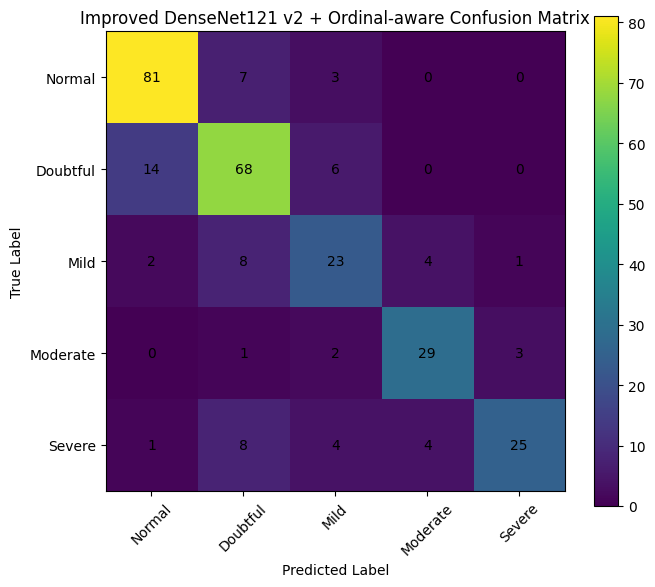

In [11]:
def predict(model, data_loader, device):
    model.eval()

    all_labels = []
    all_preds = []
    all_probs = []

    softmax = torch.nn.Softmax(dim=1)

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)

            outputs = model(images)
            probs = softmax(outputs)
            _, preds = torch.max(outputs, dim=1)

            all_labels.extend(labels.cpu().numpy().tolist())
            all_preds.extend(preds.cpu().numpy().tolist())
            all_probs.extend(probs.cpu().numpy().tolist())

    return all_labels, all_preds, all_probs


print("=" * 60)
print("Evaluating Improved DenseNet121 v2 + Ordinal-aware Loss on Test Set")
print("=" * 60)

model_path = MODEL_DIR / f"{MODEL_VERSION}_best.pth"

if not model_path.exists():
    raise FileNotFoundError(
        f"Cannot find model file: {model_path}. Please run training first."
    )

test_model = get_densenet121_improved_v2(
    num_classes=NUM_CLASSES,
    pretrained=False,
    dropout=DROPOUT,
    hidden_features=HIDDEN_FEATURES,
    fine_tune_last_block=True
).to(device)

test_model.load_state_dict(torch.load(model_path, map_location=device))

y_true, y_pred, y_probs = predict(
    model=test_model,
    data_loader=test_loader,
    device=device
)

overall_metrics, per_class_metrics, cm = calculate_classification_metrics(
    y_true=y_true,
    y_pred=y_pred,
    class_names=CLASS_NAMES
)

print("\nOverall Test Metrics:")
for key, value in overall_metrics.items():
    if isinstance(value, float):
        print(f"{key}: {value:.4f}")
    else:
        print(f"{key}: {value}")

print("\nPer-Class Metrics:")
per_class_df = pd.DataFrame(per_class_metrics)
display(per_class_df)

plt.figure(figsize=(7, 6))
plt.imshow(cm, interpolation="nearest")
plt.title("Improved DenseNet121 v2 + Ordinal-aware Confusion Matrix")
plt.colorbar()

tick_marks = range(len(CLASS_NAMES))
plt.xticks(tick_marks, CLASS_NAMES, rotation=45)
plt.yticks(tick_marks, CLASS_NAMES)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            str(cm[i, j]),
            horizontalalignment="center",
            verticalalignment="center"
        )

plt.tight_layout()
plt.show()




compare table

In [12]:
import pandas as pd

comparison_data = [
    {
        "model": "DenseNet121 + Standard CE",
        "accuracy": 0.7585,
        "macro_f1": 0.7282,
        "weighted_f1": 0.7498,
        "mae": 0.3639,
        "qwk": 0.8196,
        "total_errors": 71,
        "adjacent_errors": 46,
        "distant_errors": 25,
    },
    {
        "model": "DenseNet121 + Class-weighted CE",
        "accuracy": 0.7143,
        "macro_f1": 0.7080,
        "weighted_f1": 0.7139,
        "mae": 0.4252,
        "qwk": 0.7920,
        "total_errors": 84,
        "adjacent_errors": 55,
        "distant_errors": 29,
    },
    {
        "model": "DenseNet121 + Ordinal-aware Loss",
        "accuracy": 0.7279,
        "macro_f1": 0.7182,
        "weighted_f1": 0.7265,
        "mae": 0.3741,
        "qwk": 0.8294,
        "total_errors": 80,
        "adjacent_errors": 59,
        "distant_errors": 21,
    },
    {
        "model": "Improved DenseNet121 v1 + Ordinal-aware Loss",
        "accuracy": 0.6735,
        "macro_f1": 0.6252,
        "weighted_f1": 0.6515,
        "mae": 0.4558,
        "qwk": 0.8027,
        "total_errors": 96,
        "adjacent_errors": 70,
        "distant_errors": 26,
    },
    {
        "model": "Improved DenseNet121 v2 + Ordinal-aware Loss",
        "accuracy": 0.7687,
        "macro_f1": 0.7455,
        "weighted_f1": 0.7662,
        "mae": 0.3333,
        "qwk": 0.8354,
        "total_errors": 68,
        "adjacent_errors": 48,
        "distant_errors": 20,
    },
]

comparison_df = pd.DataFrame(comparison_data)

display(comparison_df)

comparison_table_path = RESULT_DIR / "model_comparison_table.csv"
comparison_df.to_csv(comparison_table_path, index=False)

print("Comparison table saved to:", comparison_table_path)



,model,accuracy,macro_f1,weighted_f1,mae,qwk,total_errors,adjacent_errors,distant_errors
0,DenseNet121 + Standard CE,0.7585,0.7282,0.7498,0.3639,0.8196,71,46,25
1,DenseNet121 + Class-weighted CE,0.7143,0.7080,0.7139,0.4252,0.7920,84,55,29
2,DenseNet121 + Ordinal-aware Loss,0.7279,0.7182,0.7265,0.3741,0.8294,80,59,21
3,Improved DenseNet121 v1 + Ordinal-aware Loss,0.6735,0.6252,0.6515,0.4558,0.8027,96,70,26
4,Improved DenseNet121 v2 + Ordinal-aware Loss,0.7687,0.7455,0.7662,0.3333,0.8354,68,48,20


Comparison table saved to: C:\Users\Lv043\OneDrive\Desktop\760proj\760-Group1\outputs\results\model_comparison_table.csv


,model,accuracy,macro_f1,weighted_f1,mae,qwk,total_errors,adjacent_errors,distant_errors
0,DenseNet121 + Standard CE,0.7585,0.7282,0.7498,0.3639,0.8196,71,46,25
1,DenseNet121 + Class-weighted CE,0.7143,0.7080,0.7139,0.4252,0.7920,84,55,29
2,DenseNet121 + Ordinal-aware Loss,0.7279,0.7182,0.7265,0.3741,0.8294,80,59,21
3,Improved DenseNet121 v1 + Ordinal-aware Loss,0.6735,0.6252,0.6515,0.4558,0.8027,96,70,26
4,Improved DenseNet121 v2 + Ordinal-aware Loss,0.7687,0.7455,0.7662,0.3333,0.8354,68,48,20


Comparison table saved to: C:\Users\Lv043\OneDrive\Desktop\760proj\760-Group1\outputs\results\model_comparison_table.csv


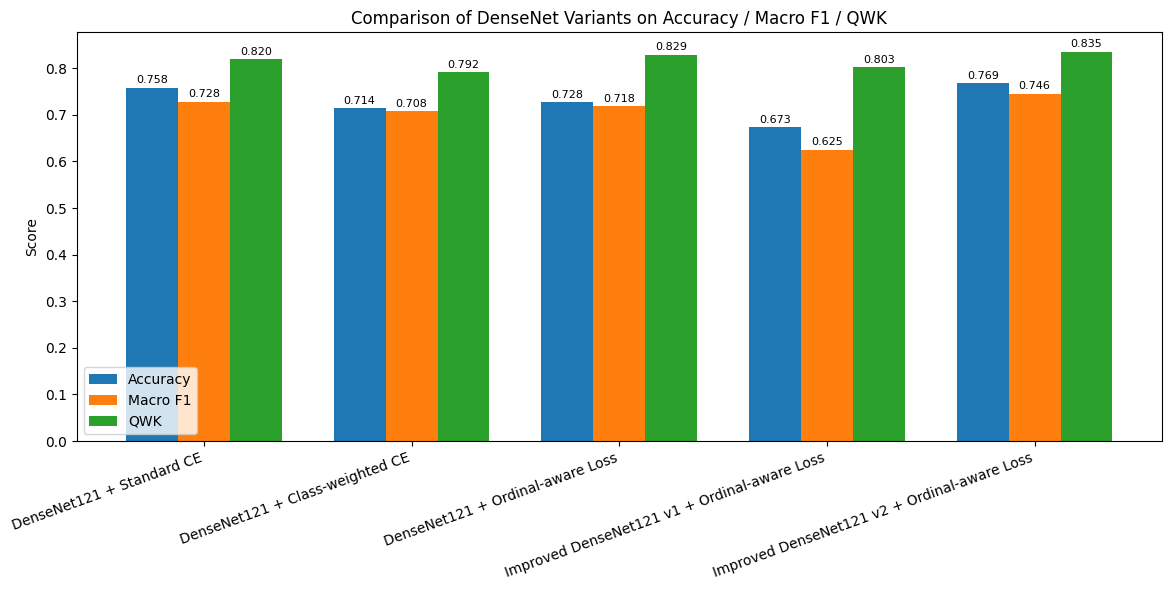

Chart A saved to: C:\Users\Lv043\OneDrive\Desktop\760proj\760-Group1\outputs\figures\densenet_variants_chart_A.png


In [13]:
import pandas as pd

comparison_data = [
    {
        "model": "DenseNet121 + Standard CE",
        "accuracy": 0.7585,
        "macro_f1": 0.7282,
        "weighted_f1": 0.7498,
        "mae": 0.3639,
        "qwk": 0.8196,
        "total_errors": 71,
        "adjacent_errors": 46,
        "distant_errors": 25,
    },
    {
        "model": "DenseNet121 + Class-weighted CE",
        "accuracy": 0.7143,
        "macro_f1": 0.7080,
        "weighted_f1": 0.7139,
        "mae": 0.4252,
        "qwk": 0.7920,
        "total_errors": 84,
        "adjacent_errors": 55,
        "distant_errors": 29,
    },
    {
        "model": "DenseNet121 + Ordinal-aware Loss",
        "accuracy": 0.7279,
        "macro_f1": 0.7182,
        "weighted_f1": 0.7265,
        "mae": 0.3741,
        "qwk": 0.8294,
        "total_errors": 80,
        "adjacent_errors": 59,
        "distant_errors": 21,
    },
    {
        "model": "Improved DenseNet121 v1 + Ordinal-aware Loss",
        "accuracy": 0.6735,
        "macro_f1": 0.6252,
        "weighted_f1": 0.6515,
        "mae": 0.4558,
        "qwk": 0.8027,
        "total_errors": 96,
        "adjacent_errors": 70,
        "distant_errors": 26,
    },
    {
        "model": "Improved DenseNet121 v2 + Ordinal-aware Loss",
        "accuracy": 0.7687,
        "macro_f1": 0.7455,
        "weighted_f1": 0.7662,
        "mae": 0.3333,
        "qwk": 0.8354,
        "total_errors": 68,
        "adjacent_errors": 48,
        "distant_errors": 20,
    },
]

comparison_df = pd.DataFrame(comparison_data)

display(comparison_df)

comparison_table_path = RESULT_DIR / "model_comparison_table.csv"
comparison_df.to_csv(comparison_table_path, index=False)

print("Comparison table saved to:", comparison_table_path)
import matplotlib.pyplot as plt
import numpy as np

models = comparison_df["model"].tolist()

x = np.arange(len(models))
width = 0.25

accuracy_vals = comparison_df["accuracy"].values
macro_f1_vals = comparison_df["macro_f1"].values
qwk_vals = comparison_df["qwk"].values

plt.figure(figsize=(12, 6))

bars1 = plt.bar(x - width, accuracy_vals, width, label="Accuracy")
bars2 = plt.bar(x, macro_f1_vals, width, label="Macro F1")
bars3 = plt.bar(x + width, qwk_vals, width, label="QWK")

plt.xticks(x, models, rotation=20, ha="right")
plt.ylabel("Score")
plt.title("Comparison of DenseNet Variants on Accuracy / Macro F1 / QWK")
plt.legend()
plt.tight_layout()

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.005,
            f"{height:.3f}",
            ha="center",
            va="bottom",
            fontsize=8
        )

chart_a_path = FIGURE_DIR / "densenet_variants_chart_A.png"
plt.savefig(chart_a_path, dpi=300, bbox_inches="tight")
plt.show()

print("Chart A saved to:", chart_a_path)



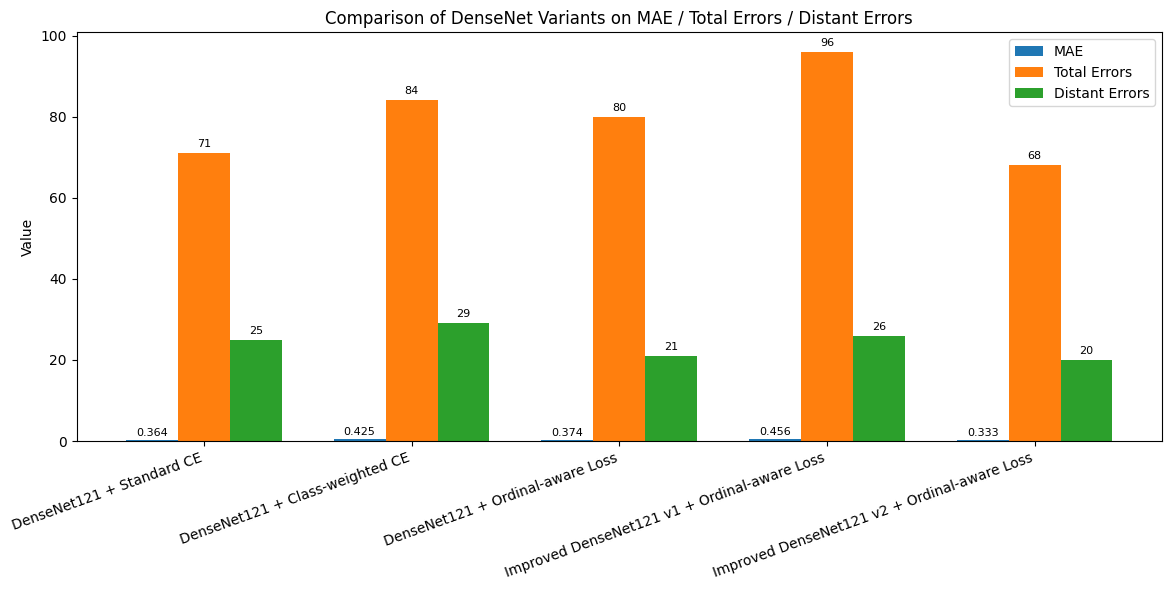

Chart B saved to: C:\Users\Lv043\OneDrive\Desktop\760proj\760-Group1\outputs\figures\densenet_variants_chart_B.png


In [14]:
models = comparison_df["model"].tolist()

x = np.arange(len(models))
width = 0.25

mae_vals = comparison_df["mae"].values
total_error_vals = comparison_df["total_errors"].values
distant_error_vals = comparison_df["distant_errors"].values

plt.figure(figsize=(12, 6))

bars1 = plt.bar(x - width, mae_vals, width, label="MAE")
bars2 = plt.bar(x, total_error_vals, width, label="Total Errors")
bars3 = plt.bar(x + width, distant_error_vals, width, label="Distant Errors")

plt.xticks(x, models, rotation=20, ha="right")
plt.ylabel("Value")
plt.title("Comparison of DenseNet Variants on MAE / Total Errors / Distant Errors")
plt.legend()
plt.tight_layout()

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        if height < 1:
            label_text = f"{height:.3f}"
            y_offset = 0.5
        else:
            label_text = f"{int(height)}"
            y_offset = 1.0

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + y_offset,
            label_text,
            ha="center",
            va="bottom",
            fontsize=8
        )

chart_b_path = FIGURE_DIR / "densenet_variants_chart_B.png"
plt.savefig(chart_b_path, dpi=300, bbox_inches="tight")
plt.show()

print("Chart B saved to:", chart_b_path)




In [16]:
import torch
import torch.nn.functional as F

def collect_test_samples(model, data_loader, device):
    model.eval()

    samples = []

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            probs = F.softmax(outputs, dim=1)
            preds = torch.argmax(outputs, dim=1)

            for i in range(images.size(0)):
                true_label = labels[i].item()
                pred_label = preds[i].item()
                confidence = probs[i, pred_label].item()

                samples.append({
                    "image_tensor": images[i].cpu(),
                    "true_label": true_label,
                    "pred_label": pred_label,
                    "confidence": confidence,
                    "error_distance": abs(pred_label - true_label),
                })

    return samples


# use current final model test_model
all_test_samples = collect_test_samples(test_model, test_loader, device)

print("Collected test samples:", len(all_test_samples))




Collected test samples: 294


select 4 sample

In [17]:
def find_first_sample(samples, condition_fn):
    for sample in samples:
        if condition_fn(sample):
            return sample
    return None

# 1. Correct KL 0
sample_correct_kl0 = find_first_sample(
    all_test_samples,
    lambda s: s["true_label"] == 0 and s["pred_label"] == 0
)

# 2. Correct KL 4
sample_correct_kl4 = find_first_sample(
    all_test_samples,
    lambda s: s["true_label"] == 4 and s["pred_label"] == 4
)

# 3. Adjacent confusion (k0 k1 error)
sample_adjacent_confusion = find_first_sample(
    all_test_samples,
    lambda s: s["pred_label"] != s["true_label"] and s["error_distance"] == 1
)

# 4. Wrong sample ( distant error)
sample_wrong = find_first_sample(
    all_test_samples,
    lambda s: s["pred_label"] != s["true_label"] and s["error_distance"] >= 2
)

# if no  distant error，any wrong sample
if sample_wrong is None:
    sample_wrong = find_first_sample(
        all_test_samples,
        lambda s: s["pred_label"] != s["true_label"]
    )

selected_samples = [
    ("Correct KL 0", sample_correct_kl0),
    ("Correct KL 4", sample_correct_kl4),
    ("Adjacent Confusion", sample_adjacent_confusion),
    ("Wrong Sample", sample_wrong),
]

for name, sample in selected_samples:
    if sample is None:
        print(f"{name}: NOT FOUND")
    else:
        print(
            f"{name}: True={sample['true_label']} ({CLASS_NAMES[sample['true_label']]}), "
            f"Pred={sample['pred_label']} ({CLASS_NAMES[sample['pred_label']]}), "
            f"Error distance={sample['error_distance']}"
        )




Correct KL 0: True=0 (Normal), Pred=0 (Normal), Error distance=0
Correct KL 4: True=4 (Severe), Pred=4 (Severe), Error distance=0
Adjacent Confusion: True=2 (Mild), Pred=1 (Doubtful), Error distance=1
Wrong Sample: True=4 (Severe), Pred=1 (Doubtful), Error distance=3


In [22]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer

        self.activations = None
        self.gradients = None

        self.forward_handle = target_layer.register_forward_hook(self.forward_hook)

    def forward_hook(self, module, input, output):
        # DenseNet have inplace ReLU，clone a output，
        # tensor return for grid to use
        output_clone = output.clone()

        self.activations = output_clone

        def backward_hook(grad):
            self.gradients = grad

        output_clone.register_hook(backward_hook)

        return output_clone

    def generate(self, input_tensor, target_class=None):
        self.model.eval()
        self.model.zero_grad()

        output = self.model(input_tensor)

        if target_class is None:
            target_class = output.argmax(dim=1).item()

        score = output[:, target_class]

        self.model.zero_grad()
        score.backward(retain_graph=True)

        gradients = self.gradients[0]      # [C, H, W]
        activations = self.activations[0]  # [C, H, W]

        weights = gradients.mean(dim=(1, 2))

        cam = torch.zeros(
            activations.shape[1:],
            dtype=torch.float32,
            device=activations.device
        )

        for i, w in enumerate(weights):
            cam += w * activations[i]

        cam = F.relu(cam)

        cam -= cam.min()
        cam /= (cam.max() + 1e-8)

        return cam.detach().cpu()

    def remove_hooks(self):
        self.forward_handle.remove()




In [23]:
# image normalize
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

def denormalize_image(img_tensor, mean=MEAN, std=STD):
    img = img_tensor.clone()

    if img.shape[0] == 1:
        mean = [0.5]
        std = [0.5]

    for c in range(img.shape[0]):
        img[c] = img[c] * std[c] + mean[c]

    img = torch.clamp(img, 0, 1)
    return img




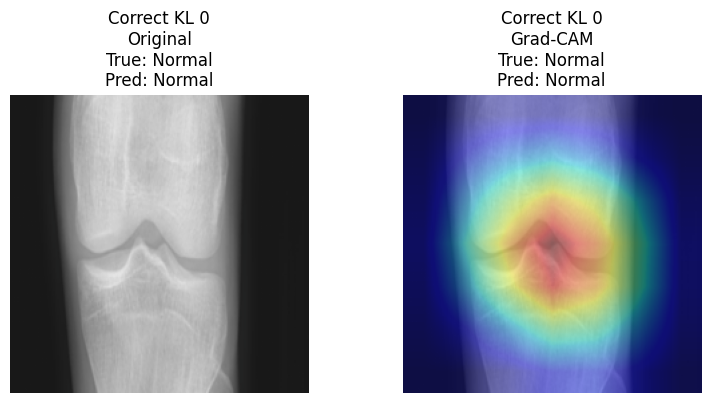

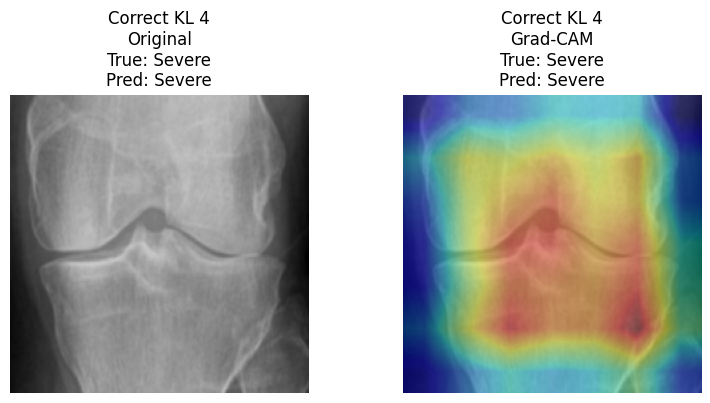

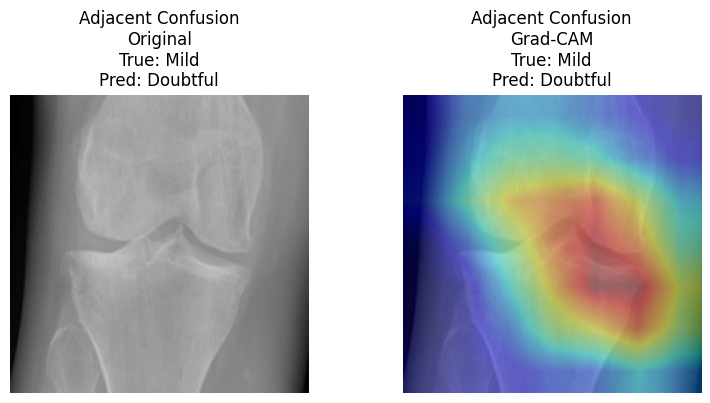

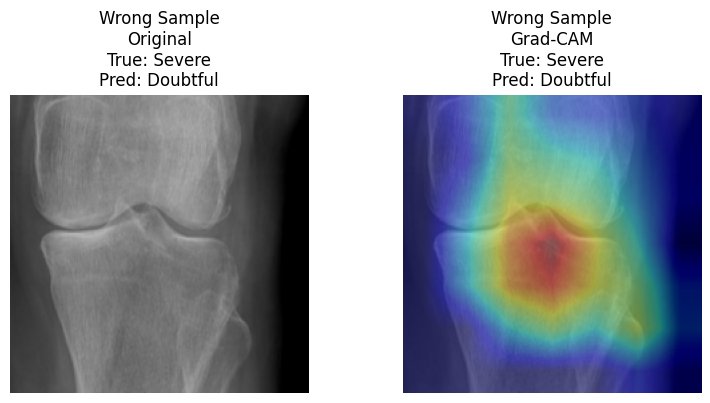

In [24]:
# target layer
target_layer = test_model.features.norm5

grad_cam = GradCAM(test_model, target_layer)


def show_gradcam(sample_title, sample, model, grad_cam, device):
    if sample is None:
        print(f"{sample_title}: sample not found")
        return

    image_tensor = sample["image_tensor"].unsqueeze(0).to(device)

    cam = grad_cam.generate(image_tensor, target_class=sample["pred_label"])

    # 原图反归一化
    original = denormalize_image(sample["image_tensor"]).permute(1, 2, 0).numpy()

    # 如果是单通道，转成 2D 便于显示
    if original.shape[2] == 1:
        original_display = original[:, :, 0]
        cmap_original = "gray"
    else:
        original_display = original
        cmap_original = None

    # resize cam to image size
    cam_resized = F.interpolate(
        cam.unsqueeze(0).unsqueeze(0),
        size=(sample["image_tensor"].shape[1], sample["image_tensor"].shape[2]),
        mode="bilinear",
        align_corners=False
    ).squeeze().numpy()

    plt.figure(figsize=(8, 4))

    # Original image
    plt.subplot(1, 2, 1)
    plt.imshow(original_display, cmap=cmap_original)
    plt.title(
        f"{sample_title}\nOriginal\n"
        f"True: {CLASS_NAMES[sample['true_label']]}\n"
        f"Pred: {CLASS_NAMES[sample['pred_label']]}"
    )
    plt.axis("off")

    # Grad-CAM overlay
    plt.subplot(1, 2, 2)
    plt.imshow(original_display, cmap=cmap_original)
    plt.imshow(cam_resized, cmap="jet", alpha=0.4)
    plt.title(
        f"{sample_title}\nGrad-CAM\n"
        f"True: {CLASS_NAMES[sample['true_label']]}\n"
        f"Pred: {CLASS_NAMES[sample['pred_label']]}"
    )
    plt.axis("off")

    plt.tight_layout()
    plt.show()


for sample_title, sample in selected_samples:
    show_gradcam(sample_title, sample, test_model, grad_cam, device)

grad_cam.remove_hooks()




In [21]:
try:
    grad_cam.remove_hooks()
    print("Old Grad-CAM hooks removed.")
except:
    print("No old Grad-CAM hooks to remove.")




Old Grad-CAM hooks removed.
